In [1]:
# Shared data loading
from data_loader import *
setup_plotting()
import os, csv, json
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 16. Element Type Analysis: Ads, Organic, Right Panel

AdSERP SERPs contain heterogeneous elements with different visual and cognitive
properties. This notebook applies ALL measurement techniques from notebooks 1–15
segmented by element type, testing Azzopardi et al.'s (SIGIR 2018) prediction
that evaluation cost differs by element type.

**Element types from ad boundary data:**
- `native_ad`: Sponsored results embedded in organic listings (95% of trials)
- `dd_top`: Top-of-page ad block (57% of trials)
- `dd_right`: Right-side panel — Knowledge Panel, Shopping sidebar (31% of trials)
- Organic: Everything not in an ad boundary

**Measurement techniques applied per element type:**
1. Fixation count, duration, dwell time
2. Saccade amplitude (survey vs evaluate phase)
3. Pupil dilation (per-fixation mean, LF/HF where available)
4. Cursor approach-retreat signatures
5. Click rate and consideration set membership
6. Saliency scores (from Scrutinizer pipeline)

In [2]:
# ── Load ad boundary data and classify fixations by element type ──────

AD_DIR = DATA_DIR / 'ad-boundary-data'
FIXATION_PUPIL_DIR = DATA_DIR / 'fixation-pupil'
SALIENCY_DIR = DATA_DIR / 'saliency'

def load_ad_boundaries(trial_id):
    """Load ad boundary regions for a trial.
    Returns dict of element_type → list of (x, y, w, h) rects."""
    path = AD_DIR / f'{trial_id}.json'
    if not path.exists():
        return {}
    d = json.load(open(path))
    regions = {}
    for etype, elements in d.items():
        rects = []
        for el in elements:
            loc = el.get('location', {})
            size = el.get('size', {})
            rects.append((loc.get('x', 0), loc.get('y', 0),
                          size.get('width', 0), size.get('height', 0)))
        if rects:
            regions[etype] = rects
    return regions

def classify_fixation(x, y, regions):
    """Classify a fixation by element type based on ad boundaries."""
    for etype, rects in regions.items():
        for rx, ry, rw, rh in rects:
            if rx <= x <= rx + rw and ry <= y <= ry + rh:
                return etype
    return 'organic'

print('Loading and classifying fixations...')
trial_ids = get_trial_ids()

# Per-fixation records with element type
all_records = []  # {trial, fix_idx, x, y, d, etype, phase, pd, pd_change, ...}

for tid in trial_ids:
    fixations = load_fixations(tid)
    if len(fixations) < 6:
        continue
    
    regions = load_ad_boundaries(tid)
    
    # Load pupil data if available
    pupil_path = FIXATION_PUPIL_DIR / f'{tid}.json'
    pupil = json.load(open(pupil_path)) if pupil_path.exists() else None
    
    # Load saliency if available
    sal_path = SALIENCY_DIR / f'{tid}.json'
    saliency = None
    if sal_path.exists():
        try:
            saliency = json.load(open(sal_path))
            if not isinstance(saliency, list): saliency = None
        except: saliency = None
    
    # Load mouse events for approach features
    events, scrolls, clicks = load_mouse_events(tid)
    click_y = clicks[-1][2] if clicks else None
    
    for i, f in enumerate(fixations):
        etype = classify_fixation(f['x'], f['y'], regions)
        phase = 'survey' if i < 5 else 'evaluate'
        
        rec = {
            'trial': tid,
            'fix_idx': i,
            'x': f['x'],
            'y': f['y'],
            'd': f['d'],
            'etype': etype,
            'phase': phase,
        }
        
        # Pupil
        if pupil and i < len(pupil) and pupil[i]['mean_pd'] is not None:
            rec['pd'] = pupil[i]['mean_pd']
            rec['pd_change'] = pupil[i]['pd_change']
        
        # Saliency (if available — requires rendering all SERPs)
        if saliency and isinstance(saliency, list) and i < len(saliency):
            s = saliency[i]
            if isinstance(s, dict):
                rec['saliency'] = s.get('saliency_mean', None)
                rec['congestion'] = s.get('congestion_mean', None)
        
        # Saccade amplitude (from previous fixation)
        if i > 0:
            prev = fixations[i-1]
            dx = f['x'] - prev['x']
            dy = f['y'] - prev['y']
            rec['saccade_amp'] = np.sqrt(dx**2 + dy**2)
        
        all_records.append(rec)

print(f'Total fixation records: {len(all_records):,}')
etypes = Counter(r['etype'] for r in all_records)
for e, n in etypes.most_common():
    print(f'  {e}: {n:,} ({n/len(all_records)*100:.1f}%)')

Loading and classifying fixations...


Total fixation records: 234,321
  organic: 169,131 (72.2%)
  dd_top: 38,760 (16.5%)
  native_ad: 14,541 (6.2%)
  dd_right: 11,889 (5.1%)


## 1. Data Census: Available Measurements by Element Type

What data do we have for each element type?

In [3]:
# Census table
etypes_list = ['organic', 'native_ad', 'dd_top', 'dd_right']
etype_labels = {'organic': 'Organic', 'native_ad': 'Native Ad', 'dd_top': 'Top Ad Block', 'dd_right': 'Right Panel'}

print(f'{"":>15} {"N fix":>10} {"w/ pupil":>10} {"w/ saliency":>12} {"w/ saccade":>12} {"mean dur":>10} {"mean Y":>10}')
print('-' * 80)
for et in etypes_list:
    recs = [r for r in all_records if r['etype'] == et]
    n = len(recs)
    n_pupil = sum(1 for r in recs if 'pd' in r)
    n_sal = sum(1 for r in recs if 'saliency' in r)
    n_sac = sum(1 for r in recs if 'saccade_amp' in r)
    mean_d = np.mean([r['d'] for r in recs]) if recs else 0
    mean_y = np.mean([r['y'] for r in recs]) if recs else 0
    print(f'{etype_labels.get(et, et):>15} {n:>10,} {n_pupil:>10,} {n_sal:>12,} {n_sac:>12,} {mean_d:>10.0f}ms {mean_y:>10.0f}px')

                     N fix   w/ pupil  w/ saliency   w/ saccade   mean dur     mean Y
--------------------------------------------------------------------------------
        Organic    169,131    158,940            0      167,392        218ms        679px
      Native Ad     14,541     13,823            0       14,320        205ms        438px
   Top Ad Block     38,760     36,760            0       37,962        217ms        331px
    Right Panel     11,889     11,282            0       11,879        234ms        496px


## 2. Fixation Properties by Element Type

Duration, count, and spatial distribution.

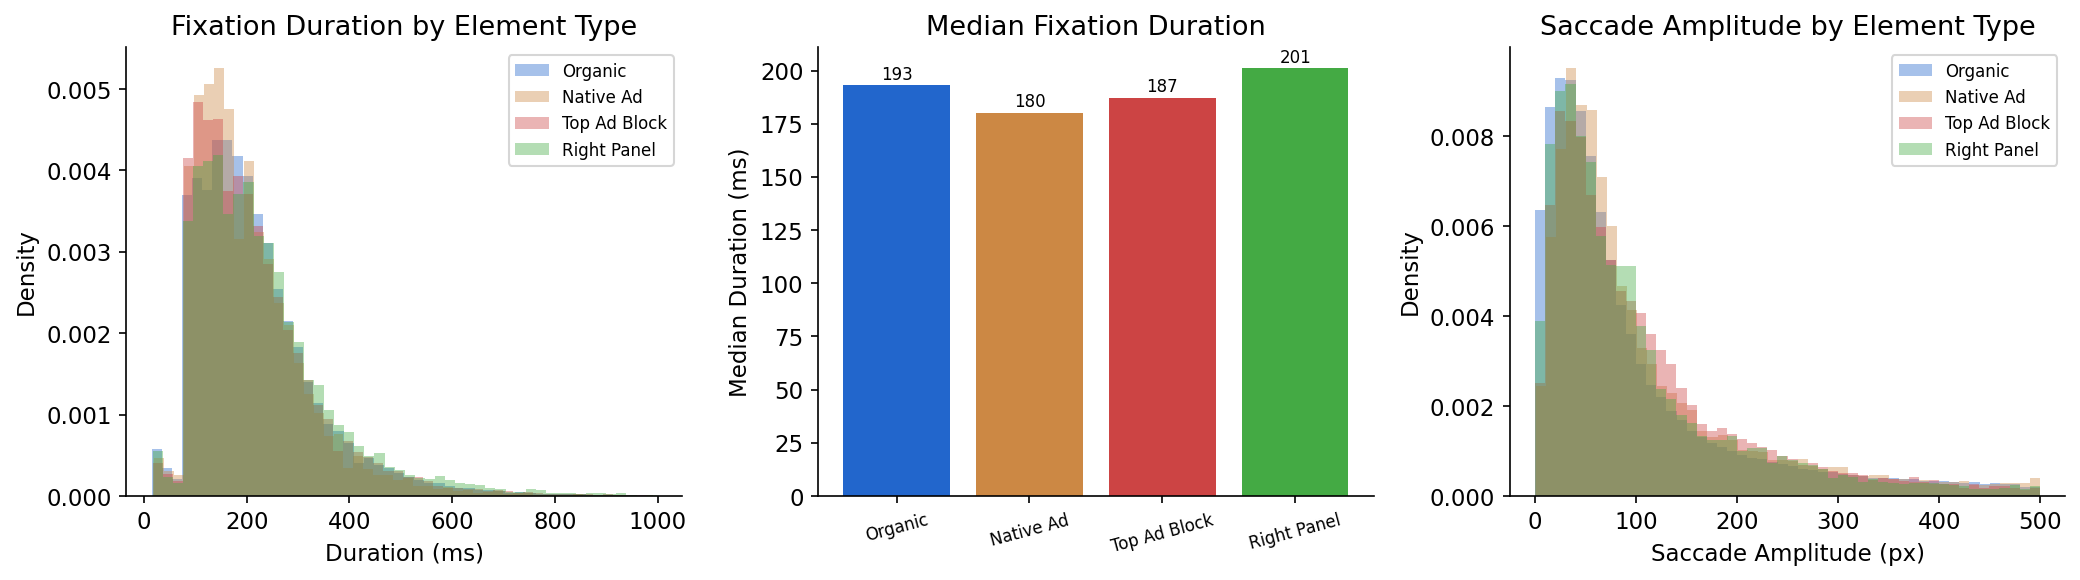


=== Duration: Kruskal-Wallis across element types ===
H = 264.0, p = 6.23e-57
          Organic: median = 193ms, N = 169,131
        Native Ad: median = 180ms, N = 14,541
     Top Ad Block: median = 187ms, N = 38,760
      Right Panel: median = 201ms, N = 11,889


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'organic': '#2266cc', 'native_ad': '#cc8844', 'dd_top': '#cc4444', 'dd_right': '#44aa44'}

# Duration distribution
for et in etypes_list:
    durs = [r['d'] for r in all_records if r['etype'] == et and r['d'] < 1000]
    if durs:
        axes[0].hist(durs, bins=50, alpha=0.4, color=colors[et], label=etype_labels[et], density=True)
axes[0].set_xlabel('Duration (ms)'); axes[0].set_ylabel('Density')
axes[0].set_title('Fixation Duration by Element Type'); axes[0].legend(fontsize=8)

# Mean duration by element type (bar chart)
means = [np.median([r['d'] for r in all_records if r['etype'] == et]) for et in etypes_list]
bars = axes[1].bar(range(len(etypes_list)), means, color=[colors[et] for et in etypes_list])
axes[1].set_xticks(range(len(etypes_list)))
axes[1].set_xticklabels([etype_labels[et] for et in etypes_list], fontsize=8, rotation=15)
axes[1].set_ylabel('Median Duration (ms)'); axes[1].set_title('Median Fixation Duration')
for bar, m in zip(bars, means): axes[1].text(bar.get_x() + bar.get_width()/2, m + 3, f'{m:.0f}', ha='center', fontsize=8)

# Saccade amplitude by element type
for et in etypes_list:
    amps = [r['saccade_amp'] for r in all_records if r['etype'] == et and 'saccade_amp' in r and r['saccade_amp'] < 500]
    if amps:
        axes[2].hist(amps, bins=50, alpha=0.4, color=colors[et], label=etype_labels[et], density=True)
axes[2].set_xlabel('Saccade Amplitude (px)'); axes[2].set_ylabel('Density')
axes[2].set_title('Saccade Amplitude by Element Type'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_etype_fixation_properties.png', dpi=200, bbox_inches='tight')
plt.show()

# Statistical tests
print('\n=== Duration: Kruskal-Wallis across element types ===')
groups = [[r['d'] for r in all_records if r['etype'] == et] for et in etypes_list]
h, p = stats.kruskal(*[g for g in groups if len(g) > 10])
print(f'H = {h:.1f}, p = {p:.2e}')
for et in etypes_list:
    durs = [r['d'] for r in all_records if r['etype'] == et]
    print(f'  {etype_labels[et]:>15}: median = {np.median(durs):.0f}ms, N = {len(durs):,}')

## 3. Pupil Dilation by Element Type

If evaluation cost differs by element type (Azzopardi's prediction),
pupil dilation should be higher for organic results (expensive text reading)
than for right-panel elements (visual/image-heavy, cheaper to process).

In [5]:
print('=== Pupil pd_change by Element Type (evaluate phase only) ===')
print(f'{"":>15} {"Median %chg":>12} {"Mean %chg":>10} {"N":>8}')
print('-' * 50)
for et in etypes_list:
    vals = [r['pd_change']*100 for r in all_records if r['etype'] == et and 'pd_change' in r and r['phase'] == 'evaluate']
    if vals:
        print(f'{etype_labels[et]:>15} {np.median(vals):>11.2f}% {np.mean(vals):>9.2f}% {len(vals):>8,}')

# Compare organic vs native_ad
org_pd = [r['pd_change'] for r in all_records if r['etype'] == 'organic' and 'pd_change' in r and r['phase'] == 'evaluate']
ad_pd = [r['pd_change'] for r in all_records if r['etype'] == 'native_ad' and 'pd_change' in r and r['phase'] == 'evaluate']
if org_pd and ad_pd:
    u, p = stats.mannwhitneyu(org_pd, ad_pd)
    print(f'\nOrganic vs Native Ad: p = {p:.2e}')
    print(f'  Organic mean: {np.mean(org_pd)*100:.2f}%, Ad mean: {np.mean(ad_pd)*100:.2f}%')

=== Pupil pd_change by Element Type (evaluate phase only) ===
                 Median %chg  Mean %chg        N
--------------------------------------------------
        Organic       -0.25%     -0.18%  152,896
      Native Ad       -0.08%      0.20%   12,617
   Top Ad Block        0.41%      0.52%   31,698
    Right Panel        0.11%     -0.03%   10,861

Organic vs Native Ad: p = 2.22e-07
  Organic mean: -0.18%, Ad mean: 0.20%


## 4. Survey Phase Fixation Targets by Element Type

Where do the first 5 fixations (survey phase) land? Does the survey
preferentially sample certain element types?

In [6]:
survey_recs = [r for r in all_records if r['phase'] == 'survey']
eval_recs = [r for r in all_records if r['phase'] == 'evaluate']

print('=== Element Type Distribution by Phase ===')
print(f'{"":>15} {"Survey":>10} {"Evaluate":>10} {"Survey %":>10} {"Eval %":>10}')
print('-' * 60)
for et in etypes_list:
    n_s = sum(1 for r in survey_recs if r['etype'] == et)
    n_e = sum(1 for r in eval_recs if r['etype'] == et)
    pct_s = n_s / len(survey_recs) * 100 if survey_recs else 0
    pct_e = n_e / len(eval_recs) * 100 if eval_recs else 0
    print(f'{etype_labels[et]:>15} {n_s:>10,} {n_e:>10,} {pct_s:>9.1f}% {pct_e:>9.1f}%')

=== Element Type Distribution by Phase ===
                    Survey   Evaluate   Survey %     Eval %
------------------------------------------------------------
        Organic      6,652    162,479      48.1%      73.7%
      Native Ad      1,292     13,249       9.3%       6.0%
   Top Ad Block      5,431     33,329      39.2%      15.1%
    Right Panel        465     11,424       3.4%       5.2%


## 5. Saliency and Congestion by Element Type

Scrutinizer's Rosenholtz Feature Congestion pipeline scores local clutter.
If available, does congestion differ by element type?

In [7]:
has_saliency = any('saliency' in r for r in all_records)
if has_saliency:
    print('=== Saliency & Congestion by Element Type ===')
    print(f'{"":>15} {"Saliency":>10} {"Congestion":>12} {"N":>8}')
    print('-' * 50)
    for et in etypes_list:
        sals = [r['saliency'] for r in all_records if r['etype'] == et and 'saliency' in r and r['saliency'] is not None]
        congs = [r['congestion'] for r in all_records if r['etype'] == et and 'congestion' in r and r['congestion'] is not None]
        if sals:
            print(f'{etype_labels[et]:>15} {np.mean(sals):>10.3f} {np.mean(congs):>12.3f} {len(sals):>8,}')
else:
    print('Saliency data not available — run export-saliency.js first.')
    print('TODO: Render all 2,776 SERPs and compute saliency scores.')

Saliency data not available — run export-saliency.js first.
TODO: Render all 2,776 SERPs and compute saliency scores.


## 6. Summary: Evaluation Cost by Element Type

Azzopardi's prediction: evaluation cost differs by element type.
Right panel (visual) < ads (familiar format) < organic (novel text).

In [8]:
print('=== Evaluation Cost Summary (evaluate phase only) ===')
print(f'{"":>15} {"Med. Dur":>10} {"Med. Sacc":>10} {"Pupil %chg":>12} {"N fix":>10}')
print('-' * 60)
for et in etypes_list:
    recs = [r for r in all_records if r['etype'] == et and r['phase'] == 'evaluate']
    if not recs:
        continue
    med_d = np.median([r['d'] for r in recs])
    sacs = [r['saccade_amp'] for r in recs if 'saccade_amp' in r]
    med_s = np.median(sacs) if sacs else 0
    pds = [r['pd_change']*100 for r in recs if 'pd_change' in r]
    med_pd = np.median(pds) if pds else 0
    print(f'{etype_labels[et]:>15} {med_d:>9.0f}ms {med_s:>9.0f}px {med_pd:>11.2f}% {len(recs):>10,}')

print('\nPrediction: Right Panel < Native Ad < Organic (increasing cost)')
print('Higher duration + smaller saccades + more pupil dilation = higher cost')

=== Evaluation Cost Summary (evaluate phase only) ===
                  Med. Dur  Med. Sacc   Pupil %chg      N fix
------------------------------------------------------------


        Organic       193ms        61px       -0.25%    162,479
      Native Ad       181ms        71px       -0.08%     13,249
   Top Ad Block       187ms        74px        0.41%     33,329
    Right Panel       201ms        71px        0.11%     11,424

Prediction: Right Panel < Native Ad < Organic (increasing cost)
Higher duration + smaller saccades + more pupil dilation = higher cost
